# An Example Physics Analysis

This notebook is an example of what post-Spyral analysis might look like. To use this notebook all four phases of Spyral *must* have been run on the data. After all of the phases are run on a dataset, it is time to do some actual physics analysis! In general physics analysis is highly specific to the experiment being run, but this notebook aims to give a little overview on what an analysis might look like if one wants to use some of the tools given by the application. 

First we import our modules we need, and define some materials for energy loss calculations. Note that the windows and gas for the IC do change from experiment to experiment.

In [1]:
from spyral.core.constants import AMU_2_MEV, QBRHO_2_P

from spyral_utils.nuclear import NuclearDataMap
from spyral_utils.nuclear.target import GasTarget, load_target, SolidTarget
from spyral_utils.plot import Histogrammer

import polars as pl
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import vector
import lmfit

%matplotlib widget
plt.close()

nuclear_map = NuclearDataMap()
# Ion Chamber entrance and exit window, thickness in ug/cm^2
ic_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# AT-TPC entrance window, thickness in ug/cm^2
attpc_window_material = SolidTarget(compound=[[1,1,14],[6,12,14],[7,14,4],[8,16,4]], thickness=1422.312, nuclear_data=nuclear_map)
# Ion Chamber gas material, pressure in Torr
ic_gas_material = GasTarget(compound=[(6,12,1),(9,18,4)], pressure=200.0, nuclear_data=nuclear_map)
ic_gas_thickness = 0.035 #m


Now we'll load our configuration. The configuration will help us define the target material (the active target) which we'll use for some energy loss analysis. We'll also use the nuclear data map to get the masses for the reactants we're interested in. This example loads the data for the reaction $^{16}\mathrm{C}\left(\mathrm{d}, \mathrm{d}\right){}^{16}\mathrm{C}$ in inverse kinematics (where $^{16}\mathrm{C}$ is the beam projectile). We also define the projectile starting energy, that is the energy from the accelerator after passing through the window foils of the AT-TPC.

In [2]:
# Set some parameters
workspace_path = Path("/home/junrui/Ptest/Spyral_workspace/v1.0/workspacedd")
solver_result_path = workspace_path / "InterpSolver" # if you use InterpSolverPhase

# Your AT-TPC target gas material
target_material_path = Path("/home/junrui/Ptest/Spyral-1.0/PID/compound_dd.json")

# Run number range (inclusive)
run_min = 3
run_max = 103
# Specify your nuclei

# The nucleus we observe (the one we fitted)
ejectile_z = 1
ejectile_a = 1

# The incoming nucleus (the beam)
projectile_z = 6
projectile_a = 16

# The target nucleus
target_z = 1
target_a = 2

# We calculate the residual for you
residual_z = target_z + projectile_z - ejectile_z
residual_a = target_a + projectile_a - ejectile_a

if residual_z < 0:
    raise Exception(f"Illegal nuclei! Residual Z: {residual_z}")
if residual_a < 1:
    raise Exception(f"Illegal nuclei! Residual A: {residual_a}")


Setup our nuclear data objects and calculate the beam energy in the AT-TPC, accounting for the energy loss through the proceeding ion chamber and AT-TPC windows. Note that if you **do not** have an ion chamber for your dataset you will need to modify this cell.

In [3]:
target_material = load_target(target_material_path, nuclear_map)
if not isinstance(target_material, GasTarget):
    print('Target error!')

ejectile = nuclear_map.get_data(ejectile_z, ejectile_a)
projectile = nuclear_map.get_data(projectile_z, projectile_a)
target = nuclear_map.get_data(target_z, target_a)
residual = nuclear_map.get_data(residual_z, residual_a)
print(f"Reaction: {target}({projectile}, {ejectile}){residual}")
print(f"Target material: {target_material.ugly_string}")

# Initial beam energy
mass_amu = projectile.mass / AMU_2_MEV # If needed, to convert beam energy in MeV/u -> MeV
proj_energy_accel = 196.0 # MeV, the beam energy from the accelerator

# The beam energy after the ic entrance window
proj_energy_ic = proj_energy_accel - ic_window_material.get_energy_loss(projectile, proj_energy_accel, np.array([0.0]))[0]
# The beam energy after the ic gas
proj_energy_ic_exit = proj_energy_ic - ic_gas_material.get_energy_loss(projectile, proj_energy_ic, np.array([ic_gas_thickness]))[0]
# The beam energy after the ic exit window
proj_energy_post_ic = proj_energy_ic_exit - ic_window_material.get_energy_loss(projectile, proj_energy_ic_exit, np.array([0.0]))[0]
# The beam energy after the AT-TPC entrace window
proj_energy_start = proj_energy_post_ic - attpc_window_material.get_energy_loss(projectile, proj_energy_post_ic, np.array([0.0]))[0]
# The beam energy at the downstream end of the AT-TPC
proj_energy_stop = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, np.array([1.0]))[0] # Energy at far end of detector
print(f"Accelerator Beam energy: {proj_energy_accel} MeV")
print(f"Beam energy after IC (2 windows + gas): {proj_energy_post_ic} MeV")
print(f"Beam energy range in AT-TPC: {proj_energy_start}-{proj_energy_stop} MeV")


Reaction: 2H(16C, 1H)17C
Target material: (Gas)2H2
Accelerator Beam energy: 196.0 MeV
Beam energy after IC (2 windows + gas): 188.3381226159758 MeV
Beam energy range in AT-TPC: 186.3913605190979-175.43725334713875 MeV


Now we'll create a histogramming system. The Histogrammer class wraps the numpy histogramming functionality. This is useful because we'll probably want to look at several runs, and neither numpy or matplotlib provide clean native functionality for this. We'll define a couple of histograms that will plot some useful data for us. 

In [4]:

grammer = Histogrammer()
grammer.add_hist2d('ke_theta', (360, 1600), ((0.0, 180.0), (0.0, 80.0)))
grammer.add_hist2d('ke_phi', (360, 1600), ((0.0, 360.0), (0.0, 80.0)))
grammer.add_hist1d('ex', 250, (-5.0, 20.0))
grammer.add_hist1d('rcs', 36, (0.0, 180.0))
grammer.add_hist1d('exa', 220, (-5.0, 17.0))
grammer.add_hist1d('chisq', 1000, (0.0, 1.0e1))
grammer.add_hist1d("vertex_z", 50, (0.0, 1.0))
grammer.add_hist2d("ex_vertex_z", (50, 100), ((-2.0, 3.0), (0.0, 1.0)))

In [5]:
grammer.add_hist2d("ex_vertex_x", (50, 100), ((-2.0, 3.0), (-0.03, 0.03)))
grammer.add_hist2d("ex_vertex_y", (50, 100), ((-2.0, 3.0), (-0.03, 0.03)))

grammer.add_hist2d("vertex_z_vertex_x", (50, 50), ((0.0, 1.0), (-0.03, 0.03)))
grammer.add_hist2d("vertex_z_vertex_y", (50, 50), ((0.0, 1.0), (-0.03, 0.03)))
grammer.add_hist2d("vertex_x_vertex_y", (50, 50), ((-0.03, 0.03), (-0.03, 0.03)))

In [6]:
#convertion from lab to center of mass
def omega(x, y, z):
    return np.sqrt(x * x + y * y + z * z - 2 * x * y - 2 * y * z - 2 * x * z)
def pow(x,y):
    return x**y



def omega(x, y, z):
    return np.sqrt(x * x + y * y + z * z - 2 * x * y - 2 * y * z - 2 * x * z)
def pow(x,y):
    return x**y
def kine_2b(m1, m2, m3, m4, K_proj, thetalab, K_eject):
   Et1 = K_proj + m1
   Et2 = m2
   Et3 = K_eject + m3
   Et4 = Et1 + Et2 - Et3
   
   s = pow(m1, 2) + pow(m2, 2) + 2 * m2 * Et1
   u = pow(m2, 2) + pow(m3, 2) - 2 * m2 * Et3

   m4_ex = np.sqrt((np.cos(thetalab) * omega(s, pow(m1, 2), pow(m2, 2)) * omega(u, pow(m2, 2), pow(m3, 2)) -
                 (s - pow(m1, 2) - pow(m2, 2)) * (pow(m2, 2) + pow(m3, 2) - u)) /
                   (2 * pow(m2, 2)) +
                s + u - pow(m2, 2))
   Ex = m4_ex - m4

   t = pow(m2, 2) + pow(m4_ex, 2) - 2 * m2 * Et4

   
   theta_cm = np.pi- np.arccos((pow(s, 2) + s * (2 * t - pow(m1, 2) - pow(m2, 2) - pow(m3, 2) - pow(m4_ex, 2)) +
                                  (pow(m1, 2) - pow(m2, 2)) * (pow(m3, 2) - pow(m4_ex, 2))) /
                                 (omega(s, pow(m1, 2), pow(m2, 2)) * omega(s, pow(m3, 2), pow(m4_ex, 2))))

   return theta_cm

Now we'll do some data analysis! Here we're going to calculate the ejectile (detected) particle kinetic energy from our fitted $B\rho$ and then combine that with the projectile kinetic energy, polar reaction angle, and masses to calculate the excitation energy of the residual nucleus. Note that we use the vertex position to calculate the distance travelled for the beam in the gas and then calculate the energy lost by the beam travelling to the reaction vertex. This data is then given to the histogrammer.

In [ ]:
target_vector = vector.array({"px": [0.0], "py": [0.0], "pz": [0.0], "E": [target.mass]})

all_ex = np.empty(0, float)
all_theta = np.empty(0, float)

for run in range(run_min, run_max+1):
    df = None
    path = solver_result_path / f"run_{run:04d}_{ejectile.isotopic_symbol}.parquet"
    if not path.exists():
        continue
    df = pl.scan_parquet(path)

    # Example of a filter on the dataset, here we filter out the edges of the detector in Z
    #df = df.filter((pl.col("vertex_z") > 0.5) & (pl.col("vertex_z") < 0.8) & ((pl.col("polar") < np.deg2rad(88.0)) | (pl.col("polar") > np.deg2rad(92.0)))).collect()
    #df = df.filter((pl.col("vertex_z") > 0.005) & (pl.col("vertex_z") < 0.995) & (pl.col("polar") > np.deg2rad(92.0))).collect()
    df = df.filter((pl.col("vertex_z") > 0.005) & (pl.col("vertex_z") < 0.995) & (pl.col("polar") < np.deg2rad(88.0))).collect()
    # Construct the projectile vectors (beam)
    vertices = df.select(['vertex_x', 'vertex_y', 'vertex_z']).to_numpy()
    distances = np.linalg.norm(vertices, axis=1)
    projectile_ke = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, distances)
    projectile_vector = vector.array({
        "px": np.zeros(len(projectile_ke)),
        "py": np.zeros(len(projectile_ke)),
        "pz": np.sqrt(projectile_ke * (projectile_ke + 2.0 * projectile.mass)),
        "E": projectile_ke + projectile.mass
    })

    # Construct the ejectile vectors (detected)
    brho = df.select('brho').to_numpy().flatten()
    momentum = df.select('brho').to_numpy().flatten() * float(ejectile.Z) * QBRHO_2_P
    kinetic_energy = np.sqrt(momentum**2.0 + ejectile.mass**2.0) - ejectile.mass
    polar = df.select('polar').to_numpy().flatten()
    az = df.select('azimuthal').to_numpy().flatten()
    cs = df.select('redchisq').to_numpy().flatten()
    ejectile_vector = vector.array({
        "px": momentum * np.sin(polar) * np.cos(az),
        "py": momentum * np.sin(polar) * np.sin(az),
        "pz": momentum * np.cos(polar),
        "E": np.sqrt(momentum**2.0 + ejectile.mass**2.0)
    })

    # Do the kinematics
    residual_vector = target_vector + projectile_vector - ejectile_vector # type: ignore
    ex = residual_vector.mass - residual.mass # Excitation energy is "extra" mass


    df = df.filter((ex >-0.5) & (ex < 1.0))#Limit Excitation energy
    # Construct the projectile vectors (beam)
    vertices = df.select(['vertex_x', 'vertex_y', 'vertex_z']).to_numpy()
    distances = np.linalg.norm(vertices, axis=1)
    projectile_ke = proj_energy_start - target_material.get_energy_loss(projectile, proj_energy_start, distances)
    projectile_vector = vector.array({
        "px": np.zeros(len(projectile_ke)),
        "py": np.zeros(len(projectile_ke)),
        "pz": np.sqrt(projectile_ke * (projectile_ke + 2.0 * projectile.mass)),
        "E": projectile_ke + projectile.mass
    })

    # Construct the ejectile vectors (detected)
    brho = df.select('brho').to_numpy().flatten()
    momentum = df.select('brho').to_numpy().flatten() * float(ejectile.Z) * QBRHO_2_P
    kinetic_energy = np.sqrt(momentum**2.0 + ejectile.mass**2.0) - ejectile.mass
    polar = df.select('polar').to_numpy().flatten()
    az = df.select('azimuthal').to_numpy().flatten()
    cs = df.select('redchisq').to_numpy().flatten()
    ejectile_vector = vector.array({
        "px": momentum * np.sin(polar) * np.cos(az),
        "py": momentum * np.sin(polar) * np.sin(az),
        "pz": momentum * np.cos(polar),
        "E": np.sqrt(momentum**2.0 + ejectile.mass**2.0)
    })

    # Do the kinematics
    residual_vector = target_vector + projectile_vector - ejectile_vector # type: ignore
    ex = residual_vector.mass - residual.mass # Excitation energy is "extra" mass


    grammer.fill_hist2d('ke_theta', np.rad2deg(polar), kinetic_energy)
    grammer.fill_hist2d('ke_theta_resid', np.rad2deg(polar), kinetic_energy)
    grammer.fill_hist2d('ke_phi', np.rad2deg(az), kinetic_energy)
    grammer.fill_hist1d('ex', ex)
    grammer.fill_hist1d("chisq", cs)
    grammer.fill_hist1d("vertex_z", vertices[:, 2])
    grammer.fill_hist2d("ex_vertex_z", ex, vertices[:, 2])
    
    grammer.fill_hist2d("ex_vertex_x", ex, vertices[:, 0])
    grammer.fill_hist2d("ex_vertex_y", ex, vertices[:, 1])
    
    grammer.fill_hist2d("vertex_z_vertex_x", vertices[:, 2], vertices[:, 0])
    grammer.fill_hist2d("vertex_z_vertex_y", vertices[:, 2], vertices[:, 1])
    grammer.fill_hist2d("vertex_x_vertex_y", vertices[:, 0], vertices[:, 1])
    
    polar_cm_16C=kine_2b(projectile.mass, target.mass, ejectile.mass, residual.mass, projectile_ke, polar, kinetic_energy)
    polar_cm_H=np.pi-polar_cm_16C
    

    
    thredown2 = 30
    threup2 = 40
    mask_down2 = np.rad2deg(polar_cm_16C) > thredown2
    mask_up2 = np.rad2deg(polar_cm_16C) < threup2
    mask2 = mask_down2 & mask_up2
    
    thre = 20
    mask_down1 = ex < thre
    
    all_ex = np.append(all_ex, ex)
    all_theta = np.append(all_theta, polar_cm_16C)

    combined_mask =  mask2 & mask_down1
    fullexa_selected = ex[combined_mask]

    

    grammer.fill_hist1d('exa', fullexa_selected)
    

We can also compare the kinematics to the expected values. Here we'll calculate the ejectile kinetic energy for a range of reaction angles. Note that in this case we cannot account for the exact beam energy after travelling through the gas without doing a form of Monte-Carlo simulation. By default we only calculate the ground state of the resiudal, however, you can add more excitations to the `residual_excitations` array to add more states to plot.

In [8]:
# Add states here!

residual_excitations = np.array([0.0, 2.15 ,2.75,12])

# Do the calculation in the center of mass
cm_angle_range = np.linspace(0., np.pi, 1000)
# Calculate envelope from range of beam energies
eject_kinematics = np.zeros((len(residual_excitations), len(cm_angle_range) * 2, 2))

# Upper limit (maximum beam energy)
beam_vec_max = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [np.sqrt(proj_energy_start * (proj_energy_start + 2.0 * projectile.mass))],
    "E": [proj_energy_start + projectile.mass]
})
parent_max = target_vector + beam_vec_max
parent_cm_max = parent_max.boostCM_of(parent_max)
for idx, ex in enumerate(residual_excitations):
    eject_e_cm_max = (ejectile.mass**2.0 - (residual.mass + ex)**2.0 + parent_cm_max.E**2.0) / (2.0 * parent_cm_max.E)
    eject_p_cm_max = np.sqrt(eject_e_cm_max**2.0 - ejectile.mass**2.0)
    eject_vec_cms_max = vector.array({
        "px": eject_p_cm_max * np.sin(cm_angle_range),
        "py": np.zeros(len(cm_angle_range)),
        "pz": eject_p_cm_max * np.cos(cm_angle_range),
        "E": np.full(len(cm_angle_range), eject_e_cm_max)
    })
    eject_vec_lab_max = eject_vec_cms_max.boost(parent_max)
    eject_kinematics[idx, :len(cm_angle_range), 0] = eject_vec_lab_max.theta
    eject_kinematics[idx, :len(cm_angle_range), 1] = eject_vec_lab_max.E - ejectile.mass

# Lower limit (minimum beam energy)
beam_vec_min = vector.array({
    "px": [0.0],
    "py": [0.0],
    "pz": [np.sqrt(proj_energy_stop * (proj_energy_stop + 2.0 * projectile.mass))],
    "E": [proj_energy_stop + projectile.mass]
})
parent_min = target_vector + beam_vec_min
parent_cm_min = parent_min.boostCM_of(parent_min)
for idx, ex in enumerate(residual_excitations):
    eject_e_cm_min = (ejectile.mass**2.0 - (residual.mass + ex)**2.0 + parent_cm_min.E**2.0) / (2.0 * parent_cm_min.E)
    eject_p_cm_min = np.sqrt(eject_e_cm_min**2.0 - ejectile.mass**2.0)
    eject_vec_cms_min = vector.array({
        "px": eject_p_cm_min * np.sin(cm_angle_range),
        "py": np.zeros(len(cm_angle_range)),
        "pz": eject_p_cm_min * np.cos(cm_angle_range),
        "E": np.full(len(cm_angle_range), eject_e_cm_min)
    })
    eject_vec_lab_min = eject_vec_cms_min.boost(parent_min)
    # Note that lower limit is "flipped". We plot the band as a polygon, so need to continue from large lab angles to small lab angles
    eject_kinematics[idx, len(cm_angle_range):, 0] = np.flip(eject_vec_lab_min.theta)
    eject_kinematics[idx, len(cm_angle_range):, 1] = np.flip(eject_vec_lab_min.E - ejectile.mass)

Now lets make some plots! Here we are showing the kinematics (energy-angle relationship) for the ejectile (detected) particle. On this histogram we also plot our calculated kinematics as a band representing the range of values over the length of the detector. Here we're looking for general agreement with the trend, not exact values.

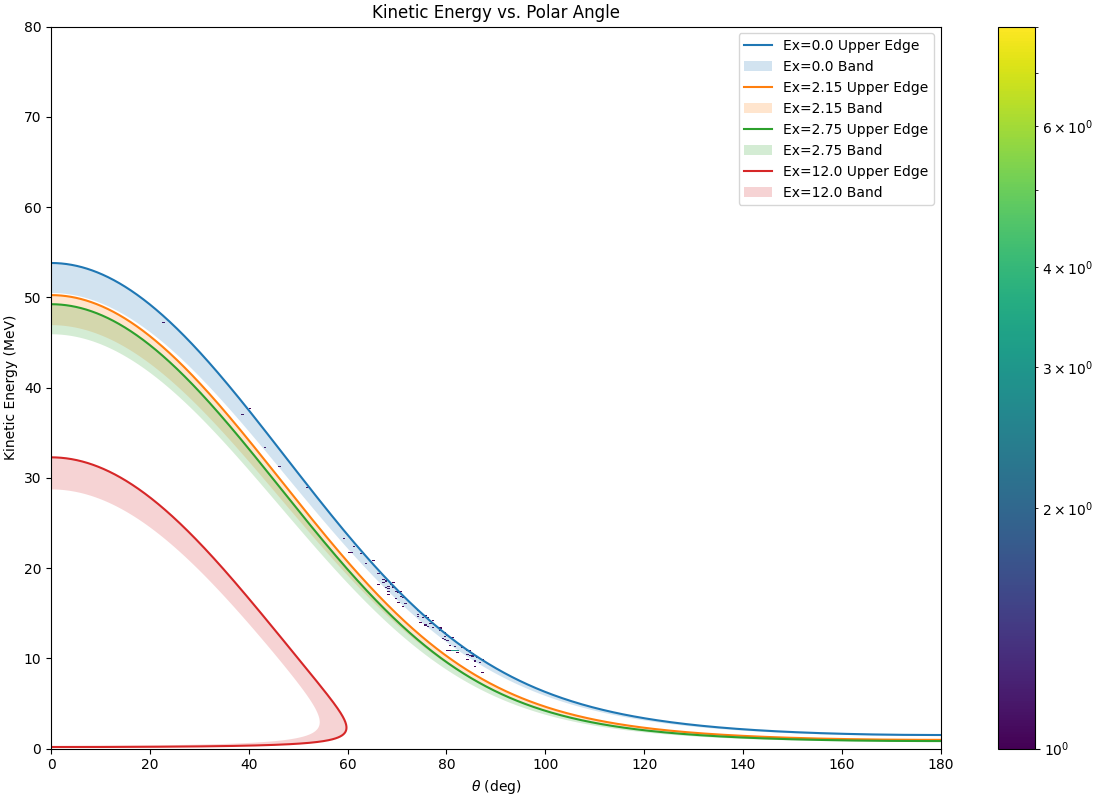

In [10]:
ke_theta = grammer.get_hist2d("ke_theta")
ke_phi = grammer.get_hist2d("ke_phi")
fig, ax = plt.subplots(1,1, constrained_layout=True)
mesh = ax.pcolormesh(ke_theta.x_bins, ke_theta.y_bins, ke_theta.counts, norm="log")
ax.set_title("Kinetic Energy vs. Polar Angle")
ax.set_xlabel(r"$\theta$ (deg)")
ax.set_ylabel("Kinetic Energy (MeV)")
fig.colorbar(mesh, ax=ax)
for idx, ex in enumerate(residual_excitations):
    ax.plot(np.rad2deg(eject_kinematics[idx, :len(cm_angle_range), 0]), eject_kinematics[idx, :len(cm_angle_range), 1], label=f"Ex={ex:02} Upper Edge")
    # Fill idea thanks to D. Ramirez
    ax.fill(np.rad2deg(eject_kinematics[idx, :, 0]), eject_kinematics[idx, :, 1], label=f"Ex={ex:02} Band", alpha=0.2)
fig.set_figheight(8.0)
fig.set_figwidth(11.0)
ax.legend()


Below are some more slices on the data. You should explore the parameter space to find correlations in your dataset.

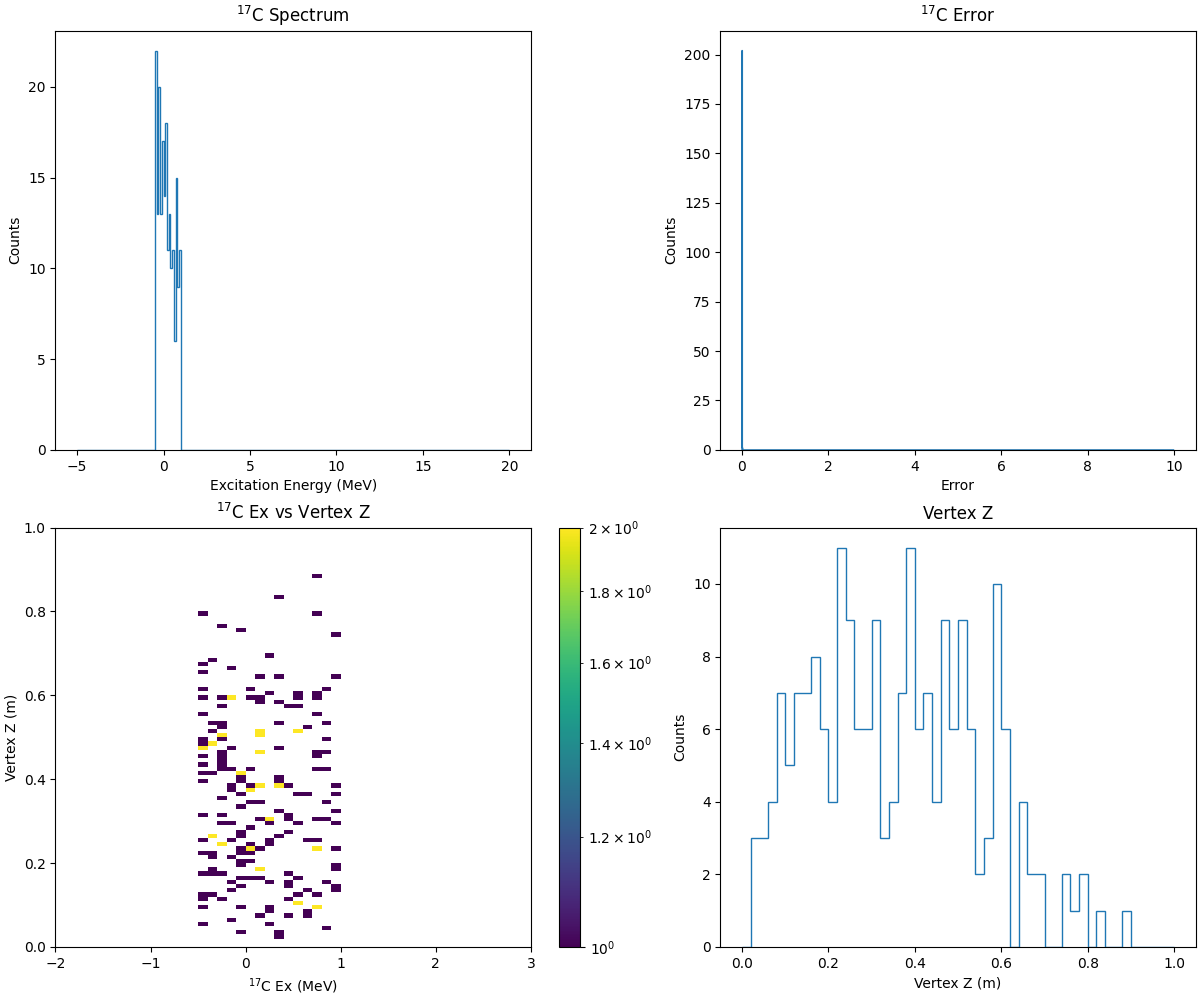

In [11]:
fig, ax = plt.subplots(2,2, constrained_layout=True)
hist = grammer.get_hist1d("ex")
ax[0][0].stairs(hist.counts, edges=hist.bins)
ax[0][0].set_title(f"{residual.get_latex_rep()} Spectrum")
ax[0][0].set_xlabel("Excitation Energy (MeV)")
ax[0][0].set_ylabel("Counts")
hist = grammer.get_hist1d("chisq")
ax[0][1].stairs(hist.counts, edges=hist.bins)
ax[0][1].set_title(f"{residual.get_latex_rep()} Error")
ax[0][1].set_xlabel("Error")
ax[0][1].set_ylabel("Counts")
hist = grammer.get_hist1d("vertex_z")
ax[1][1].stairs(hist.counts, edges=hist.bins)
ax[1][1].set_title("Vertex Z")
ax[1][1].set_xlabel("Vertex Z (m)")
ax[1][1].set_ylabel("Counts")
hist = grammer.get_hist2d("ex_vertex_z")
mesh = ax[1][0].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[1][0])
ax[1][0].set_title(f"{residual.get_latex_rep()} Ex vs Vertex Z")
ax[1][0].set_xlabel(f"{residual.get_latex_rep()} Ex (MeV)")
ax[1][0].set_ylabel("Vertex Z (m)")
fig.set_figwidth(12.0)
fig.set_figheight(10.0)

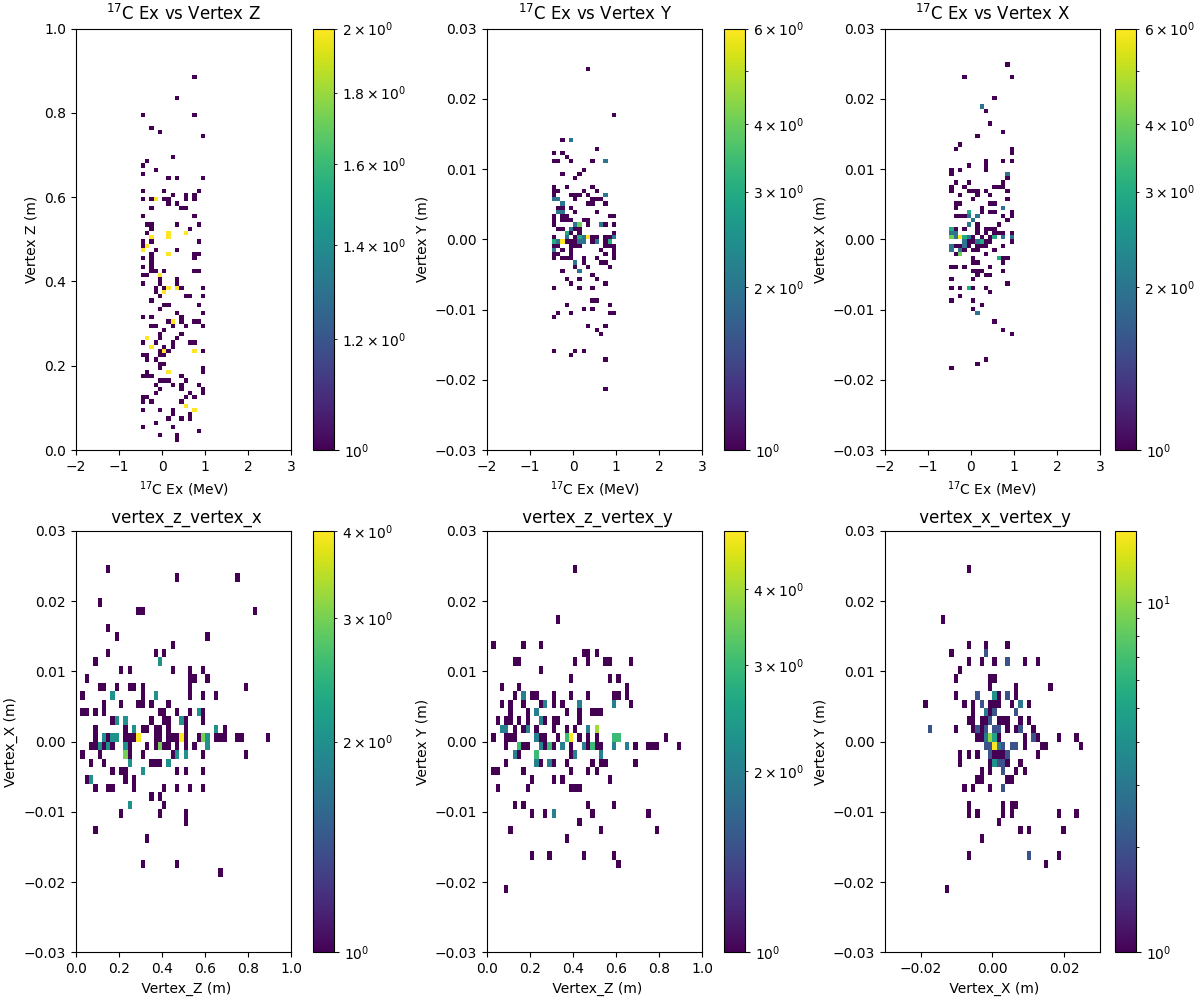

In [12]:
fig, ax = plt.subplots(2,3, constrained_layout=True)
hist = grammer.get_hist2d("ex_vertex_z")
mesh = ax[0][0].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[0][0])
ax[0][0].set_title(f"{residual.get_latex_rep()} Ex vs Vertex Z")
ax[0][0].set_xlabel(f"{residual.get_latex_rep()} Ex (MeV)")
ax[0][0].set_ylabel("Vertex Z (m)")
hist = grammer.get_hist2d("ex_vertex_y")
mesh = ax[0][1].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[0][1])
ax[0][1].set_title(f"{residual.get_latex_rep()} Ex vs Vertex Y")
ax[0][1].set_xlabel(f"{residual.get_latex_rep()} Ex (MeV)")
ax[0][1].set_ylabel("Vertex Y (m)")
hist = grammer.get_hist2d("ex_vertex_x")
mesh = ax[0][2].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[0][2])
ax[0][2].set_title(f"{residual.get_latex_rep()} Ex vs Vertex X")
ax[0][2].set_xlabel(f"{residual.get_latex_rep()} Ex (MeV)")
ax[0][2].set_ylabel("Vertex X (m)")


hist = grammer.get_hist2d("vertex_z_vertex_x")
mesh = ax[1][0].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[1][0])
ax[1][0].set_title(" vertex_z_vertex_x")
ax[1][0].set_xlabel(" Vertex_Z (m)")
ax[1][0].set_ylabel("Vertex_X (m)")
hist = grammer.get_hist2d("vertex_z_vertex_y")
mesh = ax[1][1].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[1][1])
ax[1][1].set_title(" vertex_z_vertex_y")
ax[1][1].set_xlabel(" Vertex_Z (m)")
ax[1][1].set_ylabel("Vertex Y (m)")
hist = grammer.get_hist2d("vertex_x_vertex_y")
mesh = ax[1][2].pcolormesh(hist.x_bins, hist.y_bins, hist.counts, norm="log")
fig.colorbar(mesh, ax=ax[1][2])
ax[1][2].set_title(" vertex_x_vertex_y")
ax[1][2].set_xlabel(" Vertex_X (m)")
ax[1][2].set_ylabel("Vertex Y (m)")




fig.set_figwidth(12.0)
fig.set_figheight(10.0)



Finally, below we demonstrate how to fit your excitation energy spectrum and extract some state parameters. This default tries to fit a Gaussian lineshape to a ground state peak; it may not work for your data but will provide an example of how to proceed.

In [13]:
hist = grammer.get_hist1d("exa")

peak1 = lmfit.models.GaussianModel(prefix="peak1_")
peak1_bins, peak1_counts = hist.get_subrange((-0.5, 0.5))
peak1_bins += 0.5 * hist.bin_width
peak1_weights = 1.0/np.sqrt(peak1_counts)
peak1_weights[peak1_counts == 0.0] = 1.0
pars = peak1.guess(x=peak1_bins, data=peak1_counts, weights=peak1_weights)

# Example second peak
# peak2 = lmfit.models.LorentzianModel(prefix="peak2_")
# peak2_bins, peak2_counts = hist.get_subrange((0.0, 1.0))
# peak2_bins += 0.5 * hist.bin_width
# peak2_weights = 1.0/np.sqrt(peak2_counts)
# peak2_weights[peak2_counts == 0.0] = 1.0
# pars.update(peak2.guess(x=peak2_bins, data=peak2_counts, weights=peak2_weights))


total_fit = peak1
# Example of multi peak model
# total_fit = peak1 + peak2 
total_bins, total_counts = hist.get_subrange((-1.0, 1.0))
total_bins += 0.5 * hist.bin_width
total_weights = 1.0/np.sqrt(total_counts)
total_weights[total_counts == 0.0] = 1.0
total_result = total_fit.fit(params=pars, x=total_bins, data=total_counts, weights=total_weights)
comps = total_result.eval_components(x=total_bins)
total_result


/tmp/ipykernel_57058/3805234154.py:24: RuntimeWarning: divide by zero encountered in divide
  total_weights = 1.0/np.sqrt(total_counts)


peak1_sigma 0.41018349775253427
peak1_center 0.24245845263922827
203


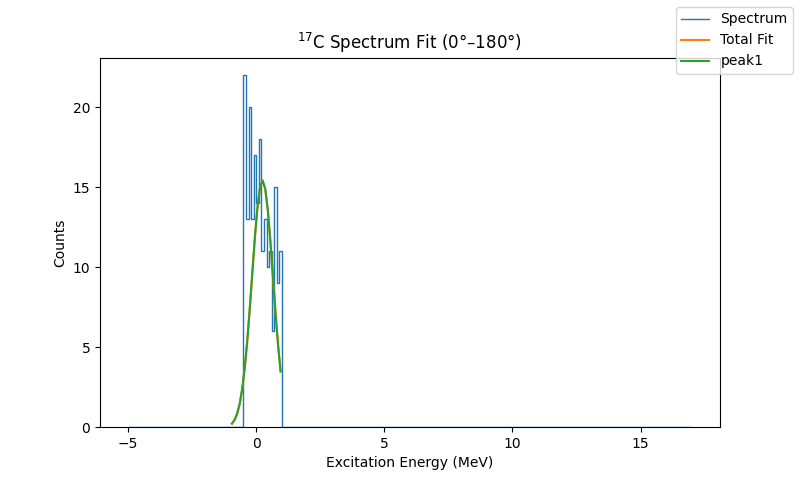

In [14]:
fig, ax = plt.subplots(1,1)
ax.stairs(hist.counts, edges=hist.bins, label="Spectrum")
ax.plot(total_bins, total_result.best_fit, label=f"Total Fit")
ax.plot(total_bins, comps["peak1_"], label="peak1")
# Example of second peak
# ax.plot(total_bins, comps["peak2_"], label="peak2")
ax.set_title(f"{residual.get_latex_rep()} Spectrum Fit ({thredown2}°–{threup2}°)")
ax.set_xlabel("Excitation Energy (MeV)")
ax.set_ylabel("Counts")
fig.set_figwidth(8.0)
fig.legend()

np.savetxt(
    "spectrum.txt",
    np.column_stack([hist.bins[:-1], hist.bins[1:], hist.counts]),
    header="bin_left  bin_right  counts"
)

peak1_sigma = total_result.params['peak1_sigma'].value
peak1_center = total_result.params['peak1_center'].value
print("peak1_sigma",peak1_sigma)
print("peak1_center",peak1_center)


peak1_height = total_result.params['peak1_height'].value

def calculate_peak_range(center, sigma):
    return (center - 3 * sigma, center + 3 * sigma)

peak1_range = calculate_peak_range(peak1_center, peak1_sigma)

peak1_total_counts = np.sum(total_counts[(total_bins >= peak1_range[0]) & (total_bins <= peak1_range[1])])

print(peak1_total_counts)

In [15]:
peak1_sigma = total_result.params['peak1_sigma'].value
peak1_center = total_result.params['peak1_center'].value
print("peak1_sigma",peak1_sigma)
print("peak1_center",peak1_center)


peak1_height = total_result.params['peak1_height'].value

def calculate_peak_range(center, sigma):
    return (center - 3 * sigma, center + 3 * sigma)

peak1_range = calculate_peak_range(peak1_center, peak1_sigma)

peak1_total_counts = np.sum(total_counts[(total_bins >= peak1_range[0]) & (total_bins <= peak1_range[1])])

print(peak1_total_counts)

peak1_sigma 0.41018349775253427
peak1_center 0.24245845263922827
203
